# crypto-image-cnn — チュートリアル

30分ぶんのオーダーフロー特徴量の窓を **画像のスタック** に変換し、CNNで
次の10秒のBTC無期限リターンを予測する(研究用スキャフォールド)。

この notebook は *流れと図* だけを担う。重い処理はすべて `src/` にあり、成果物は
`data/` にキャッシュされる — 再実行は安く、既に存在するものは再取得・再計算しない。

特徴量は **意図的に最小限**(Binance単独・生に近い量だけ)。エッジの探索は読者に委ねる。
**まず `README.md`** を読むこと(着想とリーク対策の保証について書いてある)。

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # リポジトリのルートをパスに追加

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib   # 図中の日本語表示
import torch

from src.config import Config
from src import pipeline, train
from src.data import load_bars
from src.features import compute_features
from src.target import make_target

cfg = Config()                 # 設定はすべてここ — 変えるなら src/config.py
device = "cuda" if torch.cuda.is_available() else "cpu"
print(cfg)
print("device:", device)

Config(symbol='BTCUSDT', start='2026-01-01', end='2026-04-01', bar_sec=10, horizon=1, vol_window=48, window=180, step=30, train_frac=0.7, val_frac=0.15, model='small_cnn', batch_size=64, max_epochs=200, patience=10, lr=0.001, weight_decay=0.0001, dropout=0.3, seed=42, num_workers=0)
device: cuda


## 1 · データ — 生の約定 → N秒足(Binance)

バーは Binance の **公開約定アーカイブ**(APIキー不要)から集計する。
生の約定から作ることで、OHLCVエンドポイントが捨てるミクロ構造 — taker の買い/売り
内訳と、バー内の *1秒毎* の約定回数ヒストグラム — を保持できる。
すべて `data/*.parquet` にキャッシュされる。

bars: (777600, 28)


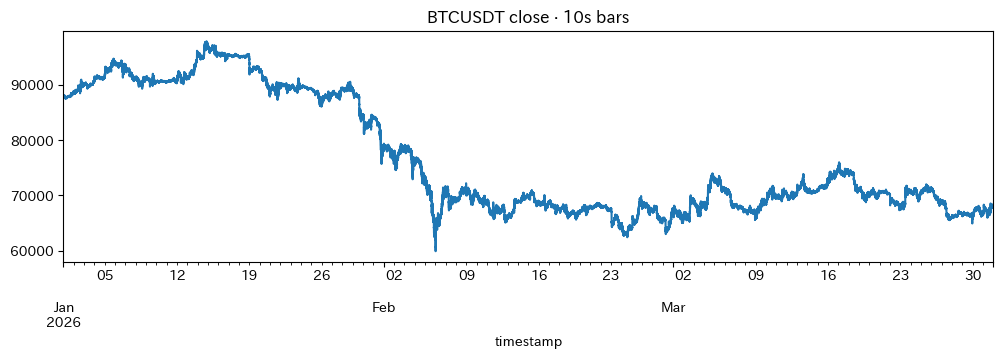

,Open,High,Low,Close,Buy_volume,Sell_volume,buy_count,sell_count,buy_count_1s_1,buy_count_1s_2,...,sell_count_1s_1,sell_count_1s_2,sell_count_1s_3,sell_count_1s_4,sell_count_1s_5,sell_count_1s_6,sell_count_1s_7,sell_count_1s_8,sell_count_1s_9,sell_count_1s_10
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00+00:00,87608.3,87611.7,87608.2,87611.6,4.039,4.108,32.0,28.0,0.0,1.0,...,0.0,1.0,5.0,2.0,2.0,1.0,2.0,3.0,7.0,5.0
2026-01-01 00:00:10+00:00,87611.6,87611.7,87600.0,87603.9,21.568,122.707,41.0,92.0,2.0,0.0,...,2.0,9.0,4.0,27.0,26.0,7.0,4.0,4.0,6.0,3.0
2026-01-01 00:00:20+00:00,87603.8,87603.9,87603.8,87603.8,1.283,4.262,12.0,23.0,0.0,1.0,...,4.0,1.0,3.0,4.0,1.0,1.0,2.0,3.0,2.0,2.0
2026-01-01 00:00:30+00:00,87603.9,87614.9,87603.9,87614.9,24.139,1.055,82.0,11.0,38.0,11.0,...,0.0,1.0,1.0,2.0,1.0,2.0,1.0,1.0,2.0,0.0
2026-01-01 00:00:40+00:00,87614.8,87614.9,87614.8,87614.9,0.855,1.114,12.0,20.0,1.0,1.0,...,1.0,2.0,3.0,3.0,4.0,3.0,2.0,1.0,1.0,0.0


In [2]:
# バー(キャッシュ付き)。初回のみ設定期間の日次アーカイブをダウンロードする。
bars = load_bars(cfg.symbol, cfg.start, cfg.end, cfg.bar_sec)
print("bars:", bars.shape)

fig, ax = plt.subplots(figsize=(12, 3))
bars["Close"].plot(ax=ax); ax.set_title(f"{cfg.symbol} close · {cfg.bar_sec}s bars"); plt.show()
bars.head()

## 2 · ターゲット — ボラティリティ正規化した forward return

`target_t = log(close_{t+h}/close_t) / sigma_t`。ここで `sigma_t` は **過去** リターン
のみのEWMA。未来を覗くのは分子だけ — それが予測対象。過去側のボラで正規化すると、
平穏な局面と荒れた局面でラベルが比較可能になる。

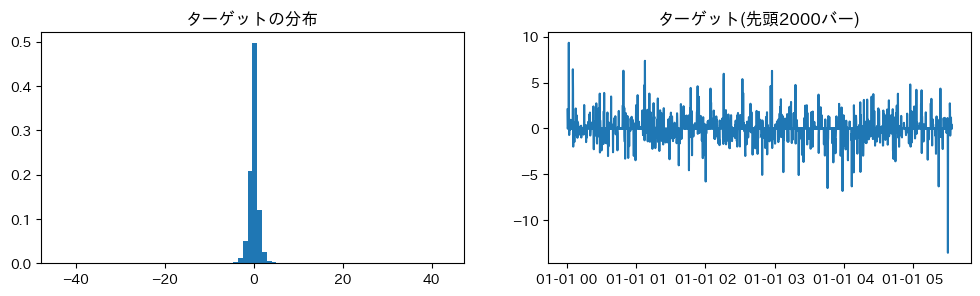

count    777597.000000
mean         -0.001764
std           1.093386
min         -43.504497
25%          -0.457460
50%           0.000000
75%           0.457373
max          42.871948
Name: target, dtype: float64

In [3]:
ret, target = make_target(bars["Close"], cfg.horizon, cfg.vol_window)
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].hist(target.dropna(), bins=80, density=True); ax[0].set_title("ターゲットの分布")
ax[1].plot(target.dropna().iloc[:2000]); ax[1].set_title("ターゲット(先頭2000バー)")
plt.show()
target.describe()

## 3 · 特徴量 — 最小・因果的

`src/features.py` は生に近い最小限の特徴量だけを作る: log_return、バー形状(高低比・
実体比)、フロー不均衡、出来高変化、1秒毎カウントの変化。いずれもバー t と t-1 だけの
点演算 / 1階差分で、**構造的にリークしえない**。テクニカル指標などのエッジ要素は
あえて入れていない — そこは読者が足す。

**検証:** すべての *未来* バーを改変し、*過去* の特徴量が1つも変わらないことを確認する。

In [4]:
# 全特徴量テーブル(binance + target)、キャッシュ付き
feat = pipeline.build_features(cfg)
print("特徴量テーブル:", feat.shape, "| 列:")
print([c for c in feat.columns if c not in ("ret", "target")])

# --- 未来改変によるリークテスト ---
base = compute_features(bars, "binance_")
bars2 = bars.copy(); cut = int(len(bars) * 0.8)
bars2.iloc[cut:, bars2.columns.get_loc("Close")] *= 1.5
pert = compute_features(bars2, "binance_")
leaks = [c for c in base.columns
         if not np.allclose(base[c].iloc[:cut - 1], pert[c].iloc[:cut - 1], atol=1e-9, equal_nan=True)]
print(f"\n未来リークした特徴量: {len(leaks)}  ->  {'合格(因果的)' if not leaks else leaks[:5]}")

  キャッシュ使用: features_BTCUSDT_10s_2026-01-01_2026-04-01.parquet


特徴量テーブル: (777597, 27) | 列:
['binance_log_return', 'binance_high_low_ratio', 'binance_open_close_ratio', 'binance_imbalance', 'binance_volume_change', 'binance_buy_count_change_1s_1', 'binance_sell_count_change_1s_1', 'binance_buy_count_change_1s_2', 'binance_sell_count_change_1s_2', 'binance_buy_count_change_1s_3', 'binance_sell_count_change_1s_3', 'binance_buy_count_change_1s_4', 'binance_sell_count_change_1s_4', 'binance_buy_count_change_1s_5', 'binance_sell_count_change_1s_5', 'binance_buy_count_change_1s_6', 'binance_sell_count_change_1s_6', 'binance_buy_count_change_1s_7', 'binance_sell_count_change_1s_7', 'binance_buy_count_change_1s_8', 'binance_sell_count_change_1s_8', 'binance_buy_count_change_1s_9', 'binance_sell_count_change_1s_9', 'binance_buy_count_change_1s_10', 'binance_sell_count_change_1s_10']



未来リークした特徴量: 0  ->  合格(因果的)


## 4 · 分割 → スケール → 窓

時系列順の 70 / 15 / 15 分割(シャッフルなし)。scaler は **train のみ** で fit し、
窓は **各分割の内部** で作るので境界をまたがない。バー *e* で終わる窓は `target_e`
(窓の直後のリターン)を予測する。

In [5]:
prepared = pipeline.prepare(cfg)
columns = prepared["columns"]
print("バー毎の特徴量数:", len(columns))

  キャッシュ使用: features_BTCUSDT_10s_2026-01-01_2026-04-01.parquet


  train: 18,138 シーケンス
  val: 3,882 シーケンス
  test: 3,883 シーケンス
バー毎の特徴量数: 25


## 5 · 時系列 → 画像(主役)

各窓を `(channels, 180, 180)` テンソルに変換する。生成は **オンザフライ**(保存しない)。
既定では4種類の変換を最小構成で示す: Gramian加算フィールド(`gaf_*`)、フロー×リターンの
相互作用フィールド(`flow_x_ret`)、1秒毎の約定回数の生マップ(`*_1s`)、ウェーブレットの
スカログラム(`cwt_*`)。チャンネルの増やし方は読者の実験対象。

チャンネル (6): ['gaf_log_return', 'gaf_volume_change', 'flow_x_ret', 'buy_1s', 'sell_1s', 'cwt_log_return']


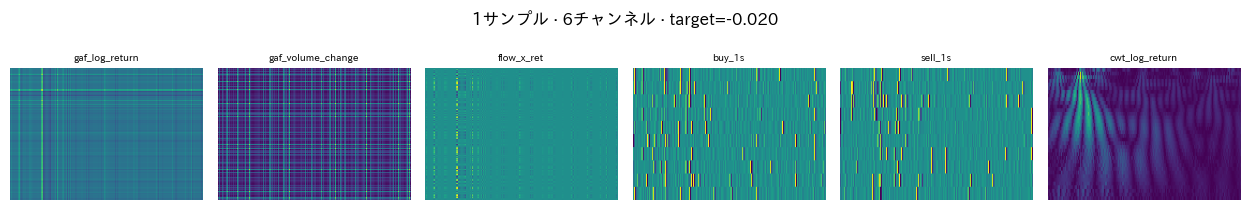

In [6]:
datasets = train.make_datasets(prepared, cfg)
ds = datasets["train"]
print(f"チャンネル ({len(ds.channel_names)}):", ds.channel_names)

img, y = ds[0]; img = img.numpy()
n = len(ds.channel_names); ncol = 6; nrow = (n + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(2.1 * ncol, 2.1 * nrow))
for ax, ch, name in zip(axes.ravel(), img, ds.channel_names):
    ax.imshow(ch, cmap="viridis", aspect="auto"); ax.set_title(name, fontsize=7); ax.axis("off")
for ax in axes.ravel()[n:]: ax.axis("off")
plt.suptitle(f"1サンプル · {n}チャンネル · target={float(y):+.3f}"); plt.tight_layout(); plt.show()

## 6–7 · モデルと学習

`small_cnn`(約0.1Mパラメータ、これくらいのサンプル数に合うサイズ)か `resnet18`
(`src/config.py` で指定)。学習は **validation** で最良エポックを選び、**test は1回だけ**
後で触る。

model=small_cnn  channels=6  params=114,273  device=cuda


  epoch   0  train 1.2149  val 1.9643  (best 1.9643)


  epoch   1  train 1.2083  val 1.9625  (best 1.9625)


  epoch   2  train 1.2069  val 1.9616  (best 1.9616)


  epoch   4  train 1.2076  val 1.9614  (best 1.9614)


...

  epoch  11  train 1.2064  val 1.9610  (best 1.9610)


  epoch  15  train 1.2045  val 1.9624  (best 1.9610)


  epoch  20  train 1.1963  val 1.9673  (best 1.9610)


  early stop @ epoch 21 (best val 1.9610)



VAL : R2 +0.0006  方向一致率 0.520
TEST: R2 -0.0008  方向一致率 0.534   (触れるのは1回だけ)


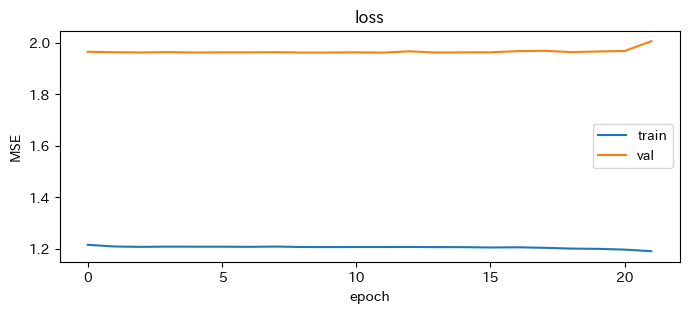

In [7]:
result = train.run(cfg, prepared, device=device)

h = result["history"]
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(h["train"], label="train"); ax.plot(h["val"], label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.legend(); ax.set_title("loss"); plt.show()

## 8 · test評価(1回)— そして誠実な読み方

`dir_acc` は方向一致率。下の曲線は `sign(pred) * target` の累積 — **コスト無視・
スケール済み単位** の健全性チェックであって、**実PnLではない**(手数料・スリッページ・
ポジションサイズなし)。test R²が小さなプラス、方向一致率が0.5をわずかに超える程度なら
「良くて弱い信号」と捉えること。

TEST · R2 -0.0008 · MAE 0.637 · 方向一致率 0.534


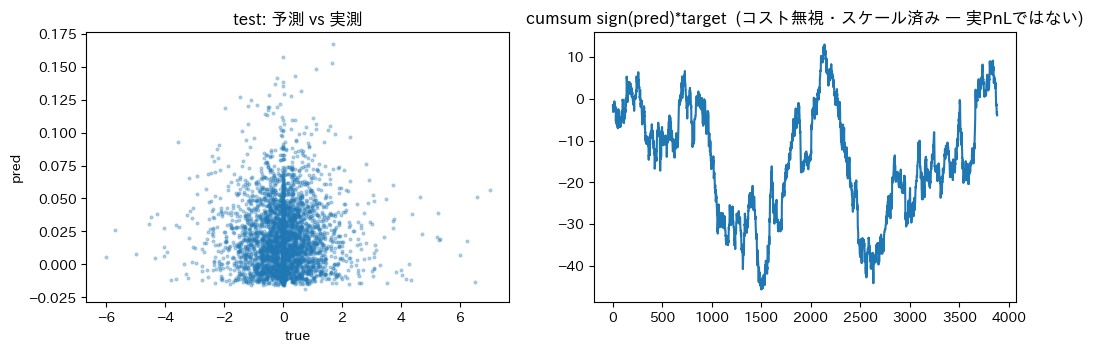

In [8]:
t = result["test"]
print(f"TEST · R2 {t['r2']:+.4f} · MAE {t['mae']:.3f} · 方向一致率 {t['dir_acc']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].scatter(t["true"], t["pred"], s=4, alpha=0.3); ax[0].set_xlabel("true"); ax[0].set_ylabel("pred")
ax[0].set_title("test: 予測 vs 実測")
ax[1].plot(np.cumsum(np.sign(t["pred"]) * t["true"]))
ax[1].set_title("cumsum sign(pred)*target  (コスト無視・スケール済み — 実PnLではない)")
plt.show()

## 9 · 本物のエッジはどこから来るか

このスキャフォールドからの誠実な学び:

* **ボトルネックは表現ではなく情報。** 窓を画像化しても情報は増えない。平坦な特徴量
  ベースラインとCNNが同じ所に着地するなら、それはモデルではなくデータが語っている。
* **特徴量は意図的に最小限。** 小さな(あるいはマイナスの)test R²はニュートラルな
  ベースラインとして当然 — ここからエッジを足すのが読者の仕事。
* **足す候補:** テクニカル指標やレジーム変数(窓を使うものは因果性に注意)、板の深さ/
  不均衡(本来的に2Dで、ネイティブな画像)、他取引所、清算、funding、そして
  mid-to-mid の次バーリターンではなく **約定を考慮したラベル**。
* 必ず **コストを考慮した** バックテスト(maker / taker / 約定保証)と **四半期毎** の
  頑健性で締めること — test 1区間は証拠にならない。